<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# Time Series Analysis - Work Along
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

## Content

### Importing required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error
import math
import random
import warnings
warnings.filterwarnings("ignore")

In [2]:
# set plotting configurations
plt.style.use('bmh')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['axes.xmargin'] = 0.
plt.rcParams['axes.ymargin'] = 0.
plt.rcParams.update({'font.size': 10})

In [3]:
# round the column to be displayed by integer
pd.options.display.float_format = '{:,.0f}'.format

Loading in the data as csv and setting the frequency,

In [4]:
ts = pd.read_csv('government_service_requests.csv')
ts.index=pd.date_range('2017-01-01', periods=len(ts), freq='W')
ts.tail()
# drop the date column


,Unnamed: 0,unemployment_claim,retail_closure
2025-11-30,2025-11-30,"42,449",10
2025-12-07,2025-12-07,"44,184",11
2025-12-14,2025-12-14,"44,875",12
2025-12-21,2025-12-21,"42,376",9
2025-12-28,2025-12-28,"42,310",9


In [5]:
# Drop the unnecessary columns
ts.drop(columns=['Unnamed: 0'], inplace=True)


### Training time series models

#### Decompose a time series with `seasonal_decompose()`

Decomposition involves breaking down a time series into its constituent parts: trend, seasonal and residual components. The `period` argument is automatically inferred, we can change this value to match the seasonality we believe the data exhibits.

Let's just decompose retail 

In [6]:
# seasonal decomposition
decomposition = seasonal_decompose(ts['retail_closure'])

Extract and plot the denoised additive model to see how well an additive composition fits the data,

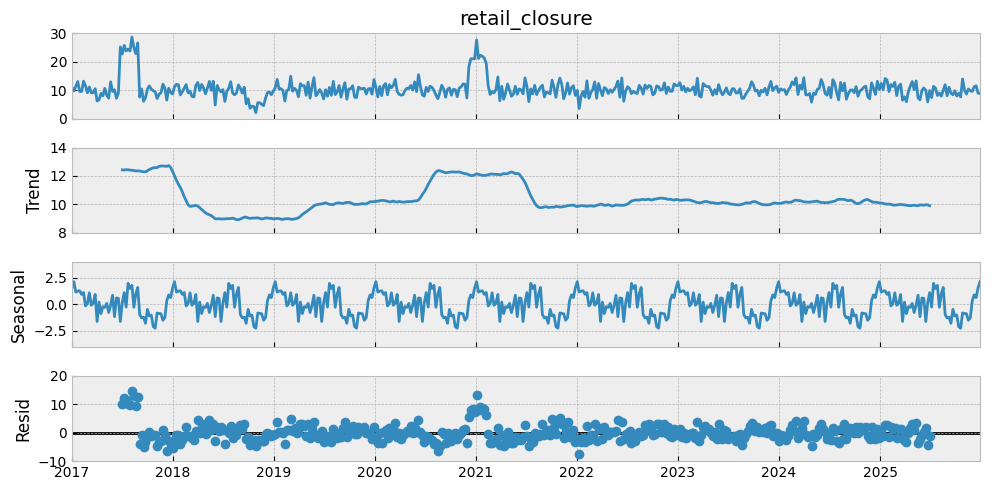

In [7]:
decomposition.plot()
plt.show()

#### Challenge: Is an additive or multiplicative decomposition best suited for this data?

- Apply a multiplicative decomposition by setting `model='m'`
- Extract the denoised multiplicative model by modifying `additive_model` and renaming to `multiplicative_model`
- Plot the denoised multiplicative model alongside the original time series
- Compare to the results of the additive decomposition, which best describes this data?

Note: If the variance of the residuals changes quite dramatically over time (known as heteroscedasticity) or shows a pattern, this suggests that the decomposition is not suitable for the data.

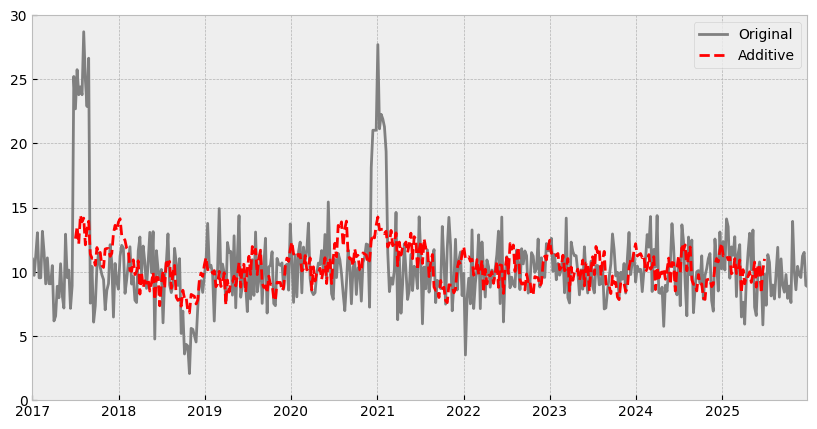

In [8]:
additive_model = decomposition.trend + decomposition.seasonal
# Plot the original time series and the additive model together to compare them. 
# The original time series is plotted in grey, while the additive model is plotted
plt.plot(ts['retail_closure'], label = 'Original', color='grey')
plt.plot(additive_model, label = 'Additive', linestyle='--', color='red')

plt.legend();

Extract and plot the denoised multiplicative model to see how well an multiplicative composition fits the data,

#### Challenge: Check for stationarity by eyeballing the time series graph

Let's plot the level of the series with a rolling window. Do you observe signs of non-stationarity?

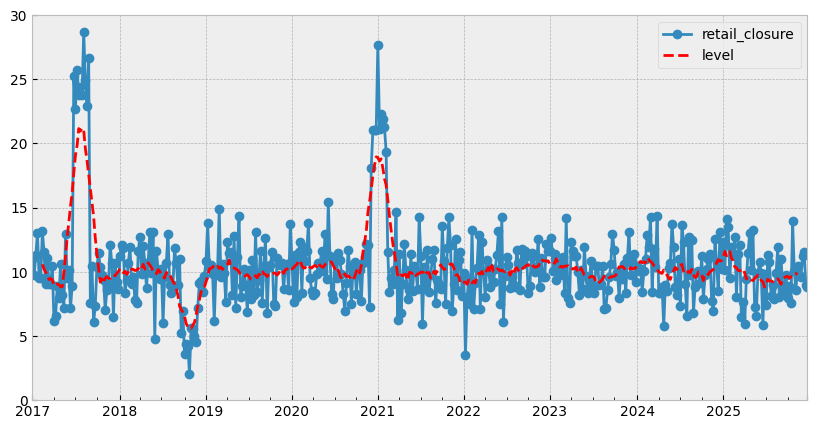

In [9]:
ts['retail_closure'].plot(marker='o');
# we can use rolling mean to estimate the level of the time series, which is the underlying trend without seasonality and noise. 
# We can use a window size of 13 to capture the yearly seasonality in the data.
level = ts['retail_closure'].rolling(window=13, center=True).mean()
level.plot(linestyle='--',label='level', color='red');
plt.legend();

#### Check for stationarity using `plot_acf()` from `statsmodels`



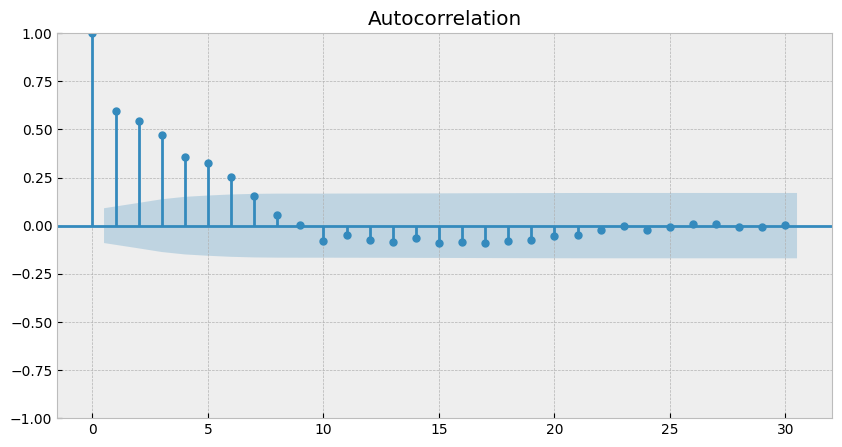

In [10]:
plot_acf(ts['retail_closure'], lags=30)
plt.show()

Run an Augmented Dickey-Fuller (ADF) test for stationarity using  `adfuller()`

In [11]:
p_value_adf = adfuller(ts['retail_closure'])[1]

print(f'ADF Test p-value: {p_value_adf:.4f}')

ADF Test p-value: 0.0000


#### Differencing a time series

We can stablise the mean of a time series through differencing `.diff()` and/or seasonal differencing `.diff(m)` to help make our time series stationary.

ARIMA models have a hyperparameter for differencing, it is important for us as analysts and programmers to determine what the hyperparameter `d` (differencing to reduce the trend) and `D` (differencing to reduce seasonality) should be.

#### Differencing with `.diff()` to reduce the trend

A way of removing/reducing trend in a time series is by differencing. Usually differencing once with `.diff()` is enough to make a time series stationary but we may need to apply second order differencing `.diff().diff()` or higher order differencing.

In [12]:
# Take the differencing on your time series data to make it stationary

#### Challenge: Re-run `ACF` and `ADF` test, is our differenced time series stationary?

- Run the ADF test again to check for stationarity.
- The ADF test does not check for seasonality, so run an ACF plot again to check for seasonality.
- Jot down any results and observations.

Run the ADF test again to check for stationarity,

The p-value is now 0.0007 which is less than 0.05, and therefore we have sufficient evidence to reject the null hypothesis that the series has a unit root and it is NOT stationary.

### Time series forecasting - training the model

### How do you build a Time Series model in python?

Split the data with the first 80% of data points in the training set and the final 20% in the test set,

In [13]:
threshold = int(len(ts['retail_closure']) * 0.8)
train = ts['retail_closure'][:threshold]
test = ts['retail_closure'][threshold:]

In [14]:
train.tail()
test.tail()

2025-11-30   10
2025-12-07   11
2025-12-14   12
2025-12-21    9
2025-12-28    9
Freq: W-SUN, Name: retail_closure, dtype: float64

#### Building a baseline time series model

First, it is good practice to establish a baseline model so that we have something to compare our model performances to.

For our baseline model we will use the Persistence Algorithm (the “naive” forecast).

This uses the previous value in the series to predict the expected outcome of the next value in the time series.

Generate the naive forecasts with `.shift()`

In [15]:
# Build your base line model on the training data
ts['naive_pred'] = ts['retail_closure'].shift(1)

In [16]:
ts[['naive_pred','retail_closure']].tail()
threshold = int(len(ts['retail_closure']) * 0.8)

ts['naive_pred'][threshold:]

2024-03-17    8
2024-03-24   12
2024-03-31   10
2024-04-07   14
2024-04-14    8
             ..
2025-11-30   10
2025-12-07   10
2025-12-14   11
2025-12-21   12
2025-12-28    9
Freq: W-SUN, Name: naive_pred, Length: 94, dtype: float64

Plot the naive forecasts for the test set,

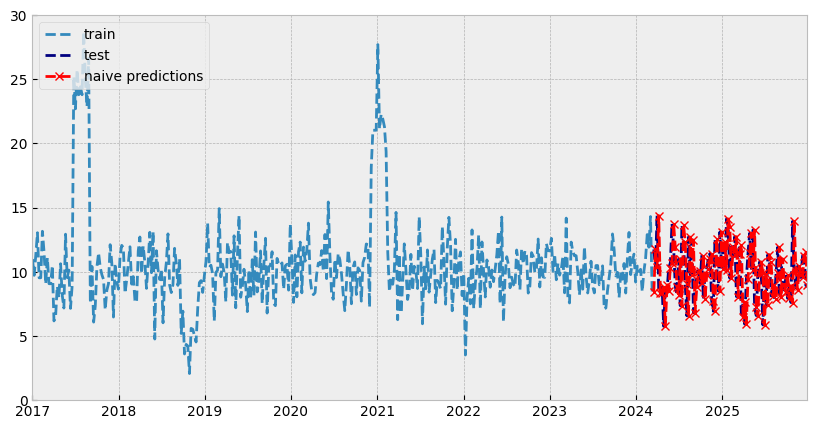

In [17]:
plt.plot(train, label="train", linestyle='--')
plt.plot(test, label="test", color="navy", linestyle='--')
# plot the naive predictions, which is the value of the previous time step, starting from the first test point
plt.plot(ts['naive_pred'][threshold:], label="naive predictions", marker = 'x', linestyle='--', color='red')
# plt.plot(ts_.naive_pred[threshold:], label="naive predictions", marker = 'x', linestyle='--', color='red')
plt.legend(loc='upper left');

To measure performance, we can use the RMSE evaluation metric by first calculating the MSE score using `mean_squared_error()` from `sklearn` and then taking the square root using `sqrt()` from `math` as follows,

In [18]:
# calculate the test score using root mean squared error (RMSE)
test_score_naive = math.sqrt(mean_squared_error(test, ts['naive_pred'][threshold:]))

# test_score = math.sqrt(mean_squared_error(test.requests, ts_.naive_pred[threshold:]))
test_score_naive

2.8602761763588975

#### Modelling with `AutoARIMA`

We can use `AutoARIMA` from `pmdarima` which will automatically determine the best hyperparameter values `(p,d,q)(P,D,Q)m`, where,

- p is the order (number of lags) incorporated into our model
- d is the degree of differencing (the number of times the data have had past values subtracted)
- q is the number of past error terms incorporated into our model
- P is the number of seasonal lags incorporated into our model
- D is the degree of seasonal differencing
- Q is the number of past seasonal error terms incorporated into our model
- m is the seasonal period

As analysts and programmers, it is good practice to determine and set `d` and `D` ourselves, as sometimes the model struggles to test and converge for these values. We should also provide a range of `p` and `q` to narrow the search space as follows,

In [19]:
#autoarima_model = pm.arima.AutoARIMA(start_p=0 ,max_p=1, d=0, start_q=0, max_q=1,
                                     start_P=0, max_P=1, D=1, start_Q=0, max_Q=1, m=13)

autoarima_model.fit(train)

KeyboardInterrupt: 

We can look at a summary of the model generated by `AutoARIMA` using `.summary()`

Generate and plot the predictions made by the `AutoArima` model,

Use RMSE evaluation metric by using `mean_squared_error()` from `sklearn` and `sqrt()` from `math` to measure performance

In [ ]:

# 

# contains the evaluation metric for the test set for arima model   
test_score_autoarima = 

Compare the RMSE scores. what does it tell?

Therefore, we know our machine learning `AutoArima`	forecasting model is performing much better than the baseline model.

#### Challenge: Report key parameters of a time series model and intepret them

What hyperparameter values were outputted from `AutoArima` and are they the best choice based on our analysis?

- p=
- d=
- q=

- P=
- D=
- Q=

- m=

#### Create the the prediction interval of ARIMA

In [ ]:
# 

predict_period = test.shape[0]+12
start_date = test.index[0]
preds, confint = autoarima_model.predict(n_periods=predict_period, return_conf_int=True)
autoarima_preds = pd.Series(preds, index=pd.date_range(start_date, periods=predict_period, freq='W'))
autoarima_confint_lower = confint[:, 0]
autoarima_confint_upper = confint[:, 1]


In [ ]:
# Create the plot of the train, test, predictions and confidence intervals
plt.plot( _______________ , label="train", linestyle='--')
plt.plot( _______________, label="test", color="navy", linestyle='--')
plt.plot( _______________ , label="AutoArima predictions", marker = 'x', linestyle='--')
plt.fill_between(autoarima_preds.index, _______________ , _____________, alpha=.3, color='red')
plt.legend(loc='upper left');

<hr /> <div style='page-break-after: always; display: none'>\pagebreak</div>

### Tree-Based Time Series Forecasting

Tree-based models like Random Forest and XGBoost can be used for time series forecasting by creating lagged features from the time series data. This transforms the forecasting problem into a supervised learning regression task.

#### Feature Engineering for Time Series
To apply tree-based models, we create features such as:
- Lagged values (e.g., value at t-1, t-2, etc.)
- Rolling statistics (e.g., moving averages)
- Seasonal indicators
- Other exogeneous indicators
- A mixture of the above


#### Implementation in Python

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [21]:
# Load the copied time series data
data = ts



#### We want to use lags as our features to build our machine learning models

In [22]:
data.head(3)

,unemployment_claim,retail_closure,naive_pred
2017-01-01,"20,952",11,NaN
2017-01-08,"19,525",10,11
2017-01-15,"21,360",11,10


In [23]:
# Create lagged 1 and 2 as features 
# fill in the lag1
data['retail_closure_lag1'] = data['retail_closure'].shift(1)
data['retail_closure_lag2'] = data['retail_closure'].shift(2)
data['moving_avg_13'] = data['retail_closure'].rolling(window=13).mean()
data['retail_closure_lag1'] = data['retail_closure'].shift(1)

# create 13 week moving average as another feature

#### Split the feature and target time series

In [24]:

# use spending as exogeneous variable to create the train test set
data = data.dropna()

# use lagged features variable to create the train test set
X = data.drop('retail_closure', axis=1)
y = data['retail_closure']


### Train test split

In [26]:

# Train-test split (use last 26 weeks for testing)
threshold = int(len(data) * 0.8)
train_size = threshold
#
# How do we split the data into train and test sets for time series forecasting?
# We need to make sure that the training set contains only data from before the test set, to avoid data leakage.
X_train, X_test = X[:threshold], X[threshold:]

# how do we split the target variable?
y_train, y_test = y[:train_size], y[train_size:]              

In [27]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=20, random_state=42)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

#### Calculate the performance using training data for Random forest

In [28]:

rf_predictions_train = rf_model.predict(X_train)
rf_mse_train = mean_squared_error(y_train, rf_predictions_train)
rf_mae_train = mean_absolute_error(y_train, rf_predictions_train)
rf_rmse_train = np.sqrt(rf_mse_train)

print(f"Random Forest - Train MSE: {rf_mse_train:.2f}, Train MAE: {rf_mae_train:.2f}, Train RMSE: {rf_rmse_train:.2f}")


Random Forest - Train MSE: 0.83, Train MAE: 0.62, Train RMSE: 0.91


In [29]:
# Let's see how the model performs on the test set

rf_predictions_test = rf_model.predict(X_test)
# Calculate metrics
rf_mse = mean_squared_error(y_test, rf_predictions_test)
rf_mae = mean_absolute_error(y_test, rf_predictions_test)
rf_rmse = np.sqrt(rf_mse)

print(f"Random Forest - MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

Random Forest - MSE: 15.65, MAE: 2.89, RMSE: 3.96


#### Evaluate the performance of Gradient Boost using train data

**Task**

* Make predictions on the time series using test data
* Create the evaluation metrics 
* Print the result

In [36]:
# Instantiate XGBoost model
gradient_model = GradientBoostingRegressor(n_estimators=20, random_state=42)
# train the model 

In [37]:
# Create the evaluation metrics for the train set
gradient_model.fit(X_train, y_train)
gradient_model_train_preds = gradient_model.predict(X_train)
gradient_model_mse_train = mean_squared_error(y_train, gradient_model_train_preds)
gradient_model_mae_train = mean_absolute_error(y_train, gradient_model_train_preds)
print(f"Gradient Boosting Train MSE: {gradient_model_mse_train:.2f}")
print(f"Gradient Boosting Train MAE: {gradient_model_mae_train:.2f}")
rf_grad = np.sqrt(gradient_model_mse_train)
print(f"Gradient Boosting Train MSAE: {rf_grad:.2f}")

Gradient Boosting Train MSE: 3.06
Gradient Boosting Train MAE: 1.34
Gradient Boosting Train MSAE: 1.75


* What do we observe from the RMSE here ? Better or worse than ARIMA and seasonal?

### Evaluate the performance using test data

In [38]:
gradient_model_predictions = gradient_model.predict(X_test)
gradient_model_mse = mean_squared_error(y_test, gradient_model_predictions)
gradient_model_mae = mean_absolute_error(y_test, gradient_model_predictions)
gradient_model_rmse = np.sqrt(gradient_model_mse)

print(f"Gradient Boosting - MSE: {gradient_model_mse:.2f}, MAE: {gradient_model_mae:.2f}, RMSE: {gradient_model_rmse:.2f}")

Gradient Boosting - MSE: 6.89, MAE: 2.15, RMSE: 2.63


#### Visualise the results

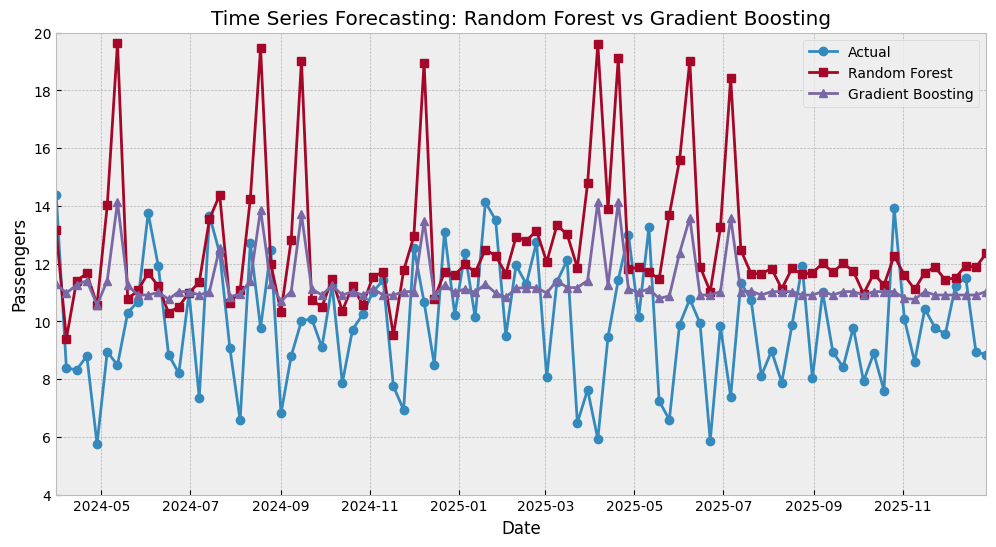

In [39]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, rf_predictions_test, label='Random Forest', marker='s')
plt.plot(y_test.index, gradient_model_predictions, label='Gradient Boosting', marker='^')
plt.title('Time Series Forecasting: Random Forest vs Gradient Boosting')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


### What do you see here? which one is better?

In [ ]:
### Write your comments on the performance of the two models and which one you would choose for this time series forecasting problem.

### Create a table to show the performance of all models

In [ ]:
# Put a table comparing the performance of all the models we have trained so far, including the naive forecast, SES, AutoARIMA, SARIMAX, Random Forest, and XGBoost. The table should include the RMSE for each model.
performance_data = {
    'Model': ['Naive Forecast', 'AutoARIMA', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [test_score_naive, test_score_autoarima,  rf_rmse_test, gradient_model_rmse]
}
performance_df = pd.DataFrame(performance_data)
print(performance_df)

#### Performance Comparison
Tree-based models offer several advantages for time series forecasting:
- **Handling Nonlinearity**: They can capture complex nonlinear patterns in the data.
- **Feature Interactions**: Automatically model interactions between lagged features.
- **Robustness**: Less sensitive to outliers compared to linear models.
- **Interpretability**: Feature importance can provide insights into which lags are most predictive.

However, they may require more computational resources and careful hyperparameter tuning. In this example, we compared Random Forest and XGBoost on the air passengers dataset. The choice between them depends on the specific dataset and computational constraints.

### Review: Time Series Analysis

#### What did we learn?

* Describe a time series as a composition between trends, seasonality and residuals
* Describe the core terminology of time series analysis e.g. lags, stationarity, decomposition etc.
* Perform autocorrelation analysis
* Build and train a time series model
* Compare and contrast various approaches to time series analysis

#### What should I learn next?

#### Practice: Time Series
In the next workshop you will gain more experience with time series decomposition, understanding stationarity, pre-processing time series data for building forecasting models, and building and evaluating an ARIMA forecasting model.


#### Learning Objectives
- Choose the best decomposition model for a time series by comparing plots and residuals
- Implement and interpret ACF plots of a time series
- Identify stationarity and test for it using the ADF test, together with ACF plot
- Make a time series stationary through differencing
- Perform the steps to fit an ARIMA forecasting model to time series data
- Evaluate the performance of an ARIMA forecasting model

## Appendix

### What packages does this chapter use?

```python
import pandas as pd
from matplotlib import pyplot as plt
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error
import math
import random
import warnings
warnings.filterwarnings("ignore")
```

---

# END